In [1]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
from oz import PyOZ
import matplotlib.pyplot as plt
import torch

Defining the Yukawa potential

In [2]:
def uYuk(r,params):
    [sigma,l, K] = params
    return torch.where(r <= sigma, torch.tensor(float('inf')), - K*torch.exp(-l*(r/sigma-1))/(r/sigma))

In [3]:
sigma=1.0
l =1.8
K = 1.0

In [4]:
HNC = PyOZ(uYuk,params=[sigma,l,K],closure='HNC')
MSA = PyOZ(uYuk,params=[sigma,l,K],closure='MSA')

Defining the grid size

In [5]:
dr = 0.001

## Comparing with RDF from MD Data Verlet 1968

In [6]:
kT = 2.0
rhob = 0.3

r, h, c = MSA.solve(rho=rhob, kBT=kT, rmax = 10.0, dr = dr)
gMSA = h + 1.0

r, h, c = HNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr = dr)
gHNC = h + 1.0

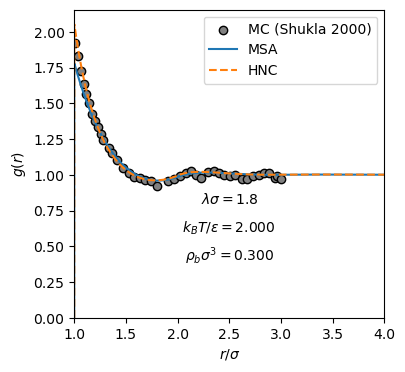

In [7]:
import pandas as pd
MCdata = pd.read_excel('data/MCdata-radialdistribution-yukawa-Shukla2000.xls',sheet_name='rhob=0.3-kT=2.0-lambda=1.8')

fig = plt.figure(figsize=(4,4))
plt.scatter(MCdata['r'],MCdata['g(r)'],marker='o',edgecolors='k',facecolors='grey',label='MC (Shukla 2000)')

plt.plot(r.cpu().numpy(),gMSA.cpu().numpy(),'-',color='C0',label='MSA')
plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'--',color='C1',label='HNC')

plt.xlim(1.0,4.0)
plt.ylim(0,None)
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(2.5,0.8,rf'$\lambda \sigma = {l:.1f}$',ha='center')
plt.text(2.5,0.6,rf'$k_B T/\epsilon = {kT:.3f}$',ha='center')
plt.text(2.5,0.4,rf'$\rho_b \sigma^3 = {rhob:.3f}$',ha='center')
plt.legend(loc='upper right',ncol=1)

In [8]:
kT = 1.0
rhob = 0.8

r, h, c = MSA.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gMSA = h + 1.0

r, h, c = HNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gHNC = h + 1.0

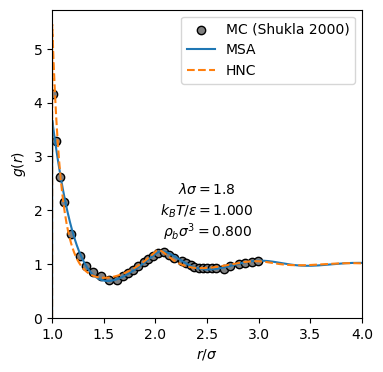

In [9]:
MCdata = pd.read_excel('data/MCdata-radialdistribution-yukawa-Shukla2000.xls',sheet_name='rhob=0.8-kT=1.0-lambda=1.8')

fig = plt.figure(figsize=(4,4))
plt.scatter(MCdata['r'],MCdata['g(r)'],marker='o',edgecolors='k',facecolors='grey',label='MC (Shukla 2000)')

plt.plot(r.cpu().numpy(),gMSA.cpu().numpy(),'-',color='C0',label='MSA')
plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'--',color='C1',label='HNC')

plt.xlim(1.0,4.0)
plt.ylim(0,None)
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(2.5,2.3,rf'$\lambda \sigma = {l:.1f}$',ha='center')
plt.text(2.5,1.9,rf'$k_B T/\epsilon = {kT:.3f}$',ha='center')
plt.text(2.5,1.5,rf'$\rho_b \sigma^3 = {rhob:.3f}$',ha='center')
plt.legend(loc='upper right',ncol=1)

In [ ]:
kT = 2.0
rhob = 0.8

r, h, c = MSA.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gMSA = h + 1.0

r, h, c = HNC.solve(rho=rhob, kBT=kT, rmax = 10.0, dr=dr)
gHNC = h + 1.0

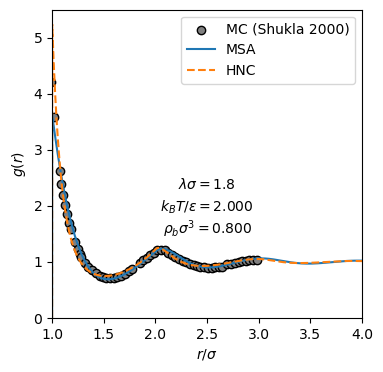

In [11]:
MCdata = pd.read_excel('data/MCdata-radialdistribution-yukawa-Shukla2000.xls',sheet_name='rhob=0.8-kT=2.0-lambda=1.8')

fig = plt.figure(figsize=(4,4))
plt.scatter(MCdata['r'],MCdata['g(r)'],marker='o',edgecolors='k',facecolors='grey',label='MC (Shukla 2000)')

plt.plot(r.cpu().numpy(),gMSA.cpu().numpy(),'-',color='C0',label='MSA')
plt.plot(r.cpu().numpy(),gHNC.cpu().numpy(),'--',color='C1',label='HNC')

plt.xlim(1.0,4.0)
plt.ylim(0,None)
plt.xlabel(r'$r/\sigma$')
plt.ylabel(r'$g(r)$')
plt.text(2.5,2.3,rf'$\lambda \sigma = {l:.1f}$',ha='center')
plt.text(2.5,1.9,rf'$k_B T/\epsilon = {kT:.3f}$',ha='center')
plt.text(2.5,1.5,rf'$\rho_b \sigma^3 = {rhob:.3f}$',ha='center')
plt.legend(loc='upper right',ncol=1)